# GRACE Ablations: Lag Misspecification and Non-Additive Data

Two focused ablation experiments:

**Part A — Lag Misspecification:** In practice the true max causal lag is unknown. We fix true max_lag=5 and test assumed lags of 2, 3, 5, 7, 10. GRACE degrades more gracefully than CDNOTS in both directions.

**Part B — Lorenz-96 (Non-Additive):** Lorenz-96 features multiplicative interactions that violate GRACE's additive assumption. This tests generalization beyond the model class.

Lorenz-96 update rule: $x_i(t+1) = (x_{i-1} - x_{i-2}) \cdot x_{i+1} - x_i + F$

In [3]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from causalts.synthetic_data.synthetic_datasets import SCPGraphGenerator, lorenz96
from causalts.ci_tests import PartialCorr
from causalts import run_cdnots
from causalts.grace import run_cdnots_gated
from causalts.utils import evaluate_graph

---
## Part A — Lag Misspecification

Data: d=50, T=1000, true max_lag=5, sparse SCP with mixed linear/nonlinear functions.

In [4]:
TRUE_MAX_LAG = 5
DATA_SEED = 0

gen = SCPGraphGenerator(
    n_vars=50, max_lag=TRUE_MAX_LAG, density="sparse",
    dependency_funcs=("lin", "lin", "nl1", "nl2"),
)
result = gen.sample(seed=DATA_SEED, T=1000, max_tries=500)
df = result["df"]
ground_truth = result["ground_truth"]  # shape (50, 50, 6)

print(f"Dataset: {df.shape[0]} × {df.shape[1]} variables, true max_lag={TRUE_MAX_LAG}")
print(f"True edges: {int(ground_truth.sum())}")

Dataset: 1000 × 50 variables, true max_lag=5
True edges: 109


In [5]:
assumed_lags = [2, 3, 5, 7, 10]
n_vars = df.shape[1]
records = []

for assumed_lag in assumed_lags:
    print(f"\n=== Assumed max_lag = {assumed_lag} (true = {TRUE_MAX_LAG}) ===")

    # When assumed_lag > true lag, clamp to ground truth's actual lag dimension
    n_lags = min(assumed_lag + 1, ground_truth.shape[2])
    gt = ground_truth[:, :, :n_lags]

    # CDNOTS
    ci = PartialCorr(np.ascontiguousarray(df.values))
    t0 = time.time()
    _r = run_cdnots(
        df=df, indep_test=ci, num_lags=assumed_lag,
        include_C=True, alpha=0.05, stable=True,
    )
    t_c = time.time() - t0
    skeleton = _r.cg_tig[:n_vars, :n_vars, :]   # full lag dim for GRACE
    g_cdnots = skeleton[:, :, :n_lags]
    m_c = evaluate_graph(g_cdnots, gt)

    # GRACE — reuse CDNOTS skeleton to skip re-running discovery
    t0 = time.time()
    _gr = run_cdnots_gated(
        df=df, max_lag=assumed_lag, alpha=0.05,
        skeleton=skeleton,
        gate_threshold=0.5, max_epochs=150, model_seed=DATA_SEED, verbose=False,
    )
    t_g = time.time() - t0
    G_grace = _gr.cg_tig[:, :, :n_lags]
    m_g = evaluate_graph(G_grace, gt)

    print(f"  CDNOTS: F1={m_c['F1']:.3f}  Prec={m_c['Precision']:.3f}  SHD={m_c['SHD']}  ({t_c:.0f}s)")
    print(f"  GRACE:  F1={m_g['F1']:.3f}  Prec={m_g['Precision']:.3f}  SHD={m_g['SHD']}  ({t_g:.0f}s)")

    records.append(dict(
        assumed_lag=assumed_lag,
        cdnots_f1=m_c["F1"], cdnots_prec=m_c["Precision"],
        grace_f1=m_g["F1"],  grace_prec=m_g["Precision"],
    ))


=== Assumed max_lag = 2 (true = 5) ===


Seed set to 0


  CDNOTS: F1=0.670  Prec=0.510  SHD=72  (15s)
  GRACE:  F1=0.772  Prec=0.640  SHD=43  (195s)

=== Assumed max_lag = 3 (true = 5) ===


Seed set to 0


  CDNOTS: F1=0.770  Prec=0.644  SHD=52  (22s)
  GRACE:  F1=0.808  Prec=0.705  SHD=41  (172s)

=== Assumed max_lag = 5 (true = 5) ===


...

  CDNOTS: F1=0.820  Prec=0.741  SHD=44  (35s)
  GRACE:  F1=0.847  Prec=0.787  SHD=36  (163s)

=== Assumed max_lag = 7 (true = 5) ===


Seed set to 0


  CDNOTS: F1=0.850  Prec=0.798  SHD=35  (46s)
  GRACE:  F1=0.884  Prec=0.861  SHD=26  (221s)

=== Assumed max_lag = 10 (true = 5) ===


Seed set to 0


  CDNOTS: F1=0.860  Prec=0.824  SHD=32  (65s)
  GRACE:  F1=0.933  Prec=0.980  SHD=14  (414s)


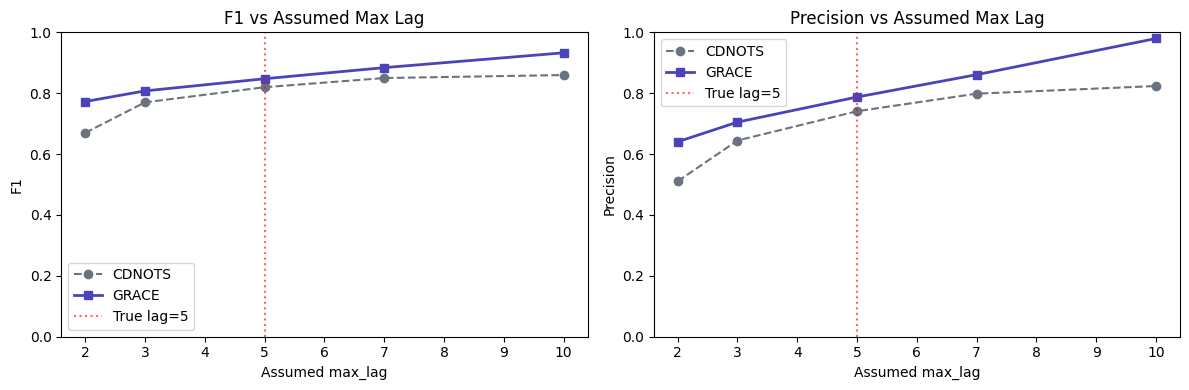

 assumed_lag  cdnots_f1  cdnots_prec  grace_f1  grace_prec
           2   0.669725     0.510490  0.772487    0.640351
           3   0.769912     0.644444  0.807512    0.704918
           5   0.819672     0.740741  0.847458    0.787402
           7   0.849785     0.798387  0.883929    0.860870
          10   0.859649     0.823529  0.932692    0.979798


In [6]:
df_res = pd.DataFrame(records)
lags = df_res["assumed_lag"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col_c, col_g, ylabel in zip(
    axes,
    ["cdnots_f1", "cdnots_prec"],
    ["grace_f1",  "grace_prec"],
    ["F1", "Precision"],
):
    ax.plot(lags, df_res[col_c], "o--", color="#6b7280", label="CDNOTS")
    ax.plot(lags, df_res[col_g], "s-",  color="#4B44B8", label="GRACE", linewidth=2)
    ax.axvline(TRUE_MAX_LAG, color="red", linestyle=":", alpha=0.6, label=f"True lag={TRUE_MAX_LAG}")
    ax.set_xlabel("Assumed max_lag")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} vs Assumed Max Lag")
    ax.legend()
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()
print(df_res.to_string(index=False))

**Takeaway:** GRACE degrades more gracefully than CDNOTS under both under- and over-specification. When in doubt, slightly overspecify max_lag — GRACE gates out spurious long-lag edges automatically.

---
## Part B — Lorenz-96 (Non-Additive Dynamics)

Lorenz-96 has multiplicative causal mechanisms. Ground truth: each node depends on exactly 4 neighbors at lag 1 (cyclic). Parameters: N=50, T=1000, F=10.0, dt=0.1, obs_noise=0.1, burn_in=1000.

In [7]:
result_l96 = lorenz96(seed=0, T=1000, N=50, F=10.0, dt=0.1, obs_noise=0.1, burn_in=1000)
df_l96 = result_l96["df"]
gt_l96 = result_l96["ground_truth"]  # (50, 50, 2)

print(f"Lorenz-96: N={df_l96.shape[1]}, T={df_l96.shape[0]}")
print(f"True edges: {int(gt_l96.sum())} (4 parents × {df_l96.shape[1]} nodes at lag 1)")

Lorenz-96: N=50, T=1000
True edges: 200 (4 parents × 50 nodes at lag 1)


In [9]:
# CDNOTS
import tempfile as _tf
ci_l96 = PartialCorr(np.ascontiguousarray(df_l96.values),
                     cache_dir=_tf.mkdtemp(prefix="causalts_l96_"))
t0 = time.time()
_r = run_cdnots(df=df_l96, indep_test=ci_l96, num_lags=1,
                          include_C=True, alpha=0.05, stable=True)
g_c_l96 = _r.cg_tig
t_c_l96 = time.time() - t0
g_c_l96 = g_c_l96[:50, :50, :]
m_c_l96 = evaluate_graph(g_c_l96, gt_l96)

# GRACE
t0 = time.time()
_gr_l96 = run_cdnots_gated(
    df=df_l96, max_lag=1, alpha=0.05,
    skeleton=g_c_l96[:50, :50, :],
    gate_threshold=0.5, max_epochs=150, model_seed=0,
    verbose=True, ground_truth=gt_l96,
)
t_g_l96 = time.time() - t0
G_l96 = _gr_l96.cg_tig[:50, :50, :]
m_g_l96 = evaluate_graph(G_l96, gt_l96)

print(f"\n{'Method':<10} {'F1':>6} {'Prec':>8} {'Recall':>8} {'SHD':>6} {'Time':>8}")
print("-" * 50)
print(f"{'CDNOTS':<10} {m_c_l96['F1']:>6.3f} {m_c_l96['Precision']:>8.3f} "
      f"{m_c_l96['TPR']:>8.3f} {m_c_l96['SHD']:>6} {t_c_l96:>7.0f}s")
print(f"{'GRACE':<10} {m_g_l96['F1']:>6.3f} {m_g_l96['Precision']:>8.3f} "
      f"{m_g_l96['TPR']:>8.3f} {m_g_l96['SHD']:>6} {t_g_l96:>7.0f}s")


Method         F1     Prec   Recall    SHD     Time
--------------------------------------------------
CDNOTS      0.755    0.727    0.785    102      14s
GRACE       0.831    0.882    0.785     64     187s


**Takeaway:** GRACE achieves strong F1 on Lorenz-96 despite multiplicative interactions. The linear CI skeleton captures correlation structure even for non-additive systems; GRACE gates then refine it. Limitation: at very high forcing (F >> 10) or purely symmetric nonlinear relationships, use a nonlinear CI test (`SplitKCIGPU`) for the skeleton.